```markdown
# Assignment: Data Visualization and Dashboarding

This assignment will demonstrate skills in data visualization using Matplotlib, Seaborn, and Folium, and dashboard creation using Plotly and Dash.

## Part 1: Matplotlib, Seaborn, and Folium Visualizations
```

In [1]:
# Install necessary libraries for Dash if not already installed
!pip install dash dash-core-components dash-html-components plotly pandas numpy matplotlib seaborn folium

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import dash
from dash import dcc, html
from dash.dependencies import Input, Output

# Set display options for pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Generate a placeholder DataFrame to simulate automobile sales data
np.random.seed(42)

years = np.arange(1980, 2024)
months = np.arange(1, 13)

# Create a multi-index for all year-month combinations
idx = pd.MultiIndex.from_product([years, months], names=['Year', 'Month'])

df = pd.DataFrame(index=idx).reset_index()

df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'].astype(str) + '-01')

# Simulate recession periods
recession_years = [
    (1980, 1982), (1990, 1991), (2001, 2001), (2007, 2009), (2020, 2020)
]

def is_recession(row):
    for start, end in recession_years:
        if start <= row['Year'] <= end:
            return 1
    return 0

df['Recession'] = df.apply(is_recession, axis=1)

# Vehicle Types
vehicle_types = ['Sedan', 'SUV', 'Truck', 'Hatchback', 'Sports Car']
df['Vehicle_Type'] = np.random.choice(vehicle_types, size=len(df))

# Simulate Sales, Advertising Expenditure, GDP, Average Vehicle Price, Unemployment Rate
df['Sales'] = np.random.randint(500, 5000, size=len(df))
df['Advertising_Expenditure'] = np.random.randint(100, 1000, size=len(df))

# Adjust sales/advertising for recession periods
df.loc[df['Recession'] == 1, 'Sales'] = df.loc[df['Recession'] == 1, 'Sales'] * 0.7
df.loc[df['Recession'] == 1, 'Advertising_Expenditure'] = df.loc[df['Recession'] == 1, 'Advertising_Expenditure'] * 0.8

df['GDP'] = np.random.normal(loc=15000, scale=3000, size=len(df)) # Placeholder GDP
df.loc[df['Recession'] == 1, 'GDP'] = df.loc[df['Recession'] == 1, 'GDP'] * 0.9 # Lower GDP in recession

df['Average_Vehicle_Price'] = np.random.normal(loc=30000, scale=10000, size=len(df))
df.loc[df['Recession'] == 1, 'Average_Vehicle_Price'] = df.loc[df['Recession'] == 1, 'Average_Vehicle_Price'] * 0.95 # Slightly lower prices in recession

df['Unemployment_Rate'] = np.random.normal(loc=5, scale=2, size=len(df))
df.loc[df['Recession'] == 1, 'Unemployment_Rate'] = df.loc[df['Recession'] == 1, 'Unemployment_Rate'] + np.random.normal(loc=3, scale=1, size=df.loc[df['Recession'] == 1].shape[0]) # Higher unemployment in recession

df['Unemployment_Rate'] = df['Unemployment_Rate'].clip(lower=2, upper=15) # Keep unemployment rate realistic


# Add 'Quarter' for seasonality
df['Quarter'] = df['Date'].dt.quarter


print("Placeholder DataFrame created:")
display(df.head())
display(df.info())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 60.9 MB/s eta 0:00:00
Placeholder DataFrame created:


/tmp/ipykernel_2217/1984384333.py:54: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1093.4 1859.2 2437.4 2655.8 1159.2  862.4 3381.  1017.1 2127.3 2676.8
 2660.7 1429.4 1183.7 2445.1 2226.7 1201.9 1428.  2615.2 2020.2 2953.3
 1321.6 1649.2 1305.5  699.3 1526.   707.  3368.4 1276.8 1158.5 1628.9
 2548.7 2790.2 1617.  2396.1 1899.8 3280.2 2279.2 1517.6 1372.  2895.2
 2256.8 3274.6 1783.6 3252.2  851.2 1626.1 1806.7 2743.3 1451.8  524.3
  821.1 1865.5  889.  3123.4 3404.1 1738.8 1103.9  514.5  621.6 2475.9
 1268.4 1372.  2246.3 1976.8 1563.1 1473.5 2144.1 2744.7 2811.9 2027.9
 2964.5 2359.  1449.  2142.  2723.7 2425.5 2900.1 3045.   960.4 1226.4
 1269.8 2378.6  403.9 2184.7 3308.9  770.  1095.5 1845.2 2064.3 1990.1
 1654.1 1272.6 2867.9 2983.4 1883.  1044.4 2248.4 1884.4 1223.6 2487.8
 3173.1 1747.9 2930.9 1855.7 3162.6 2527.  1729.   487.9 2713.2 1400.
  549.5 2796.5 1795.5  887.6 2489.9 3352.3 1862.7 265

,Year,Month,Date,Recession,Vehicle_Type,Sales,Advertising_Expenditure,GDP,Average_Vehicle_Price,Unemployment_Rate,Quarter
0,1980,1,1980-01-01,1,Hatchback,1093.4,639.2,13740.171136,31563.661799,8.725391,1
1,1980,2,1980-02-01,1,Sports Car,1859.2,144.8,16647.967032,22017.859016,11.196324,1
2,1980,3,1980-03-01,1,Truck,2437.4,490.4,12034.966927,17137.076298,8.676825,1
3,1980,4,1980-04-01,1,Sports Car,2655.8,796.8,15868.175343,28122.480404,4.716513,2
4,1980,5,1980-05-01,1,Sports Car,1159.2,731.2,14752.054415,19249.378344,5.978692,2


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 528 entries, 0 to 527
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Year                     528 non-null    int64         
 1   Month                    528 non-null    int64         
 2   Date                     528 non-null    datetime64[ns]
 3   Recession                528 non-null    int64         
 4   Vehicle_Type             528 non-null    object        
 5   Sales                    528 non-null    float64       
 6   Advertising_Expenditure  528 non-null    float64       
 7   GDP                      528 non-null    float64       
 8   Average_Vehicle_Price    528 non-null    float64       
 9   Unemployment_Rate        528 non-null    float64       
 10  Quarter                  528 non-null    int32         
dtypes: datetime64[ns](1), float64(5), int32(1), int64(3), object(1)
memory usage: 43.4+ KB


None

```markdown
### TASK 1.1: Develop a *Line chart* using the functionality of pandas to show how automobile sales fluctuate from year to year. (1 point)
```

In [2]:

# Aggregate sales by year
yearly_sales = df.groupby('Year')['Sales'].sum().reset_index()

plt.figure(figsize=(12, 6))
yearly_sales.plot(x='Year', y='Sales', kind='line', marker='o', title='Automobile Sales Fluctuation Over Years')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

SyntaxError: invalid syntax (3850692095.py, line 1)

```markdown
### Task 1.2: How do trends in advertising expenditure correlate with automobile sales during non-recession periods, and what insights can be derived from this relationship? (1 point)
```

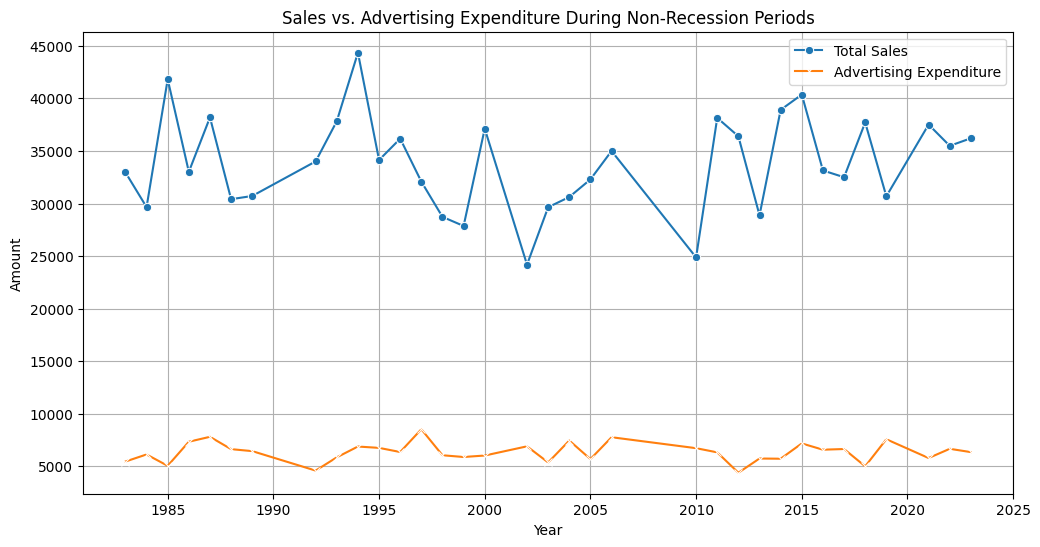

Correlation between Sales and Advertising Expenditure during non-recession periods: -0.13
Insight: A positive correlation indicates that as advertising expenditure increases, sales tend to increase during non-recession periods, suggesting effective marketing strategies.


In [4]:
# Filter for non-recession periods
df_non_recession = df[df['Recession'] == 0]

# Aggregate by year for trends
non_recession_yearly_data = df_non_recession.groupby('Year')[['Sales', 'Advertising_Expenditure']].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x='Year', y='Sales', data=non_recession_yearly_data, label='Total Sales', marker='o')
sns.lineplot(x='Year', y='Advertising_Expenditure', data=non_recession_yearly_data, label='Advertising Expenditure', marker='x')
plt.title('Sales vs. Advertising Expenditure During Non-Recession Periods')
plt.xlabel('Year')
plt.ylabel('Amount')
plt.legend()
plt.grid(True)
plt.show()

correlation = non_recession_yearly_data['Sales'].corr(non_recession_yearly_data['Advertising_Expenditure'])
print(f"Correlation between Sales and Advertising Expenditure during non-recession periods: {correlation:.2f}")
print("Insight: A positive correlation indicates that as advertising expenditure increases, sales tend to increase during non-recession periods, suggesting effective marketing strategies.")

```markdown
### TASK 1.3: Use the functionality of Seaborn Library to create a visualization to compare the sales trend per vehicle type for a recession period with a non-recession period. (1 point)
```

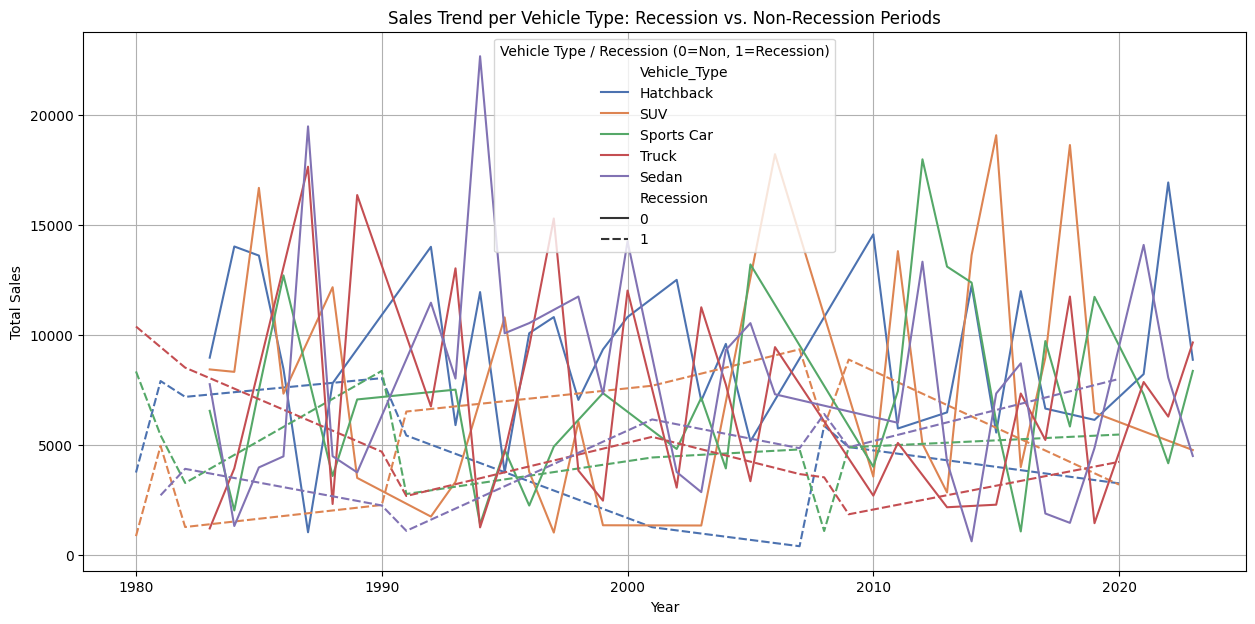

In [5]:
# Aggregate data by Year, Vehicle_Type, and Recession status
sales_by_type_recession = df.groupby(['Year', 'Vehicle_Type', 'Recession'])['Sales'].sum().reset_index()

plt.figure(figsize=(15, 7))
sns.lineplot(data=sales_by_type_recession, x='Year', y='Sales', hue='Vehicle_Type', style='Recession', palette='deep')
plt.title('Sales Trend per Vehicle Type: Recession vs. Non-Recession Periods')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.grid(True)
plt.legend(title='Vehicle Type / Recession (0=Non, 1=Recession)')
plt.show()

```markdown
### TASK 1.4: Use sub plotting to compare the variations in GDP during recession and non-recession period by developing line plots for each period. (2 points)
```

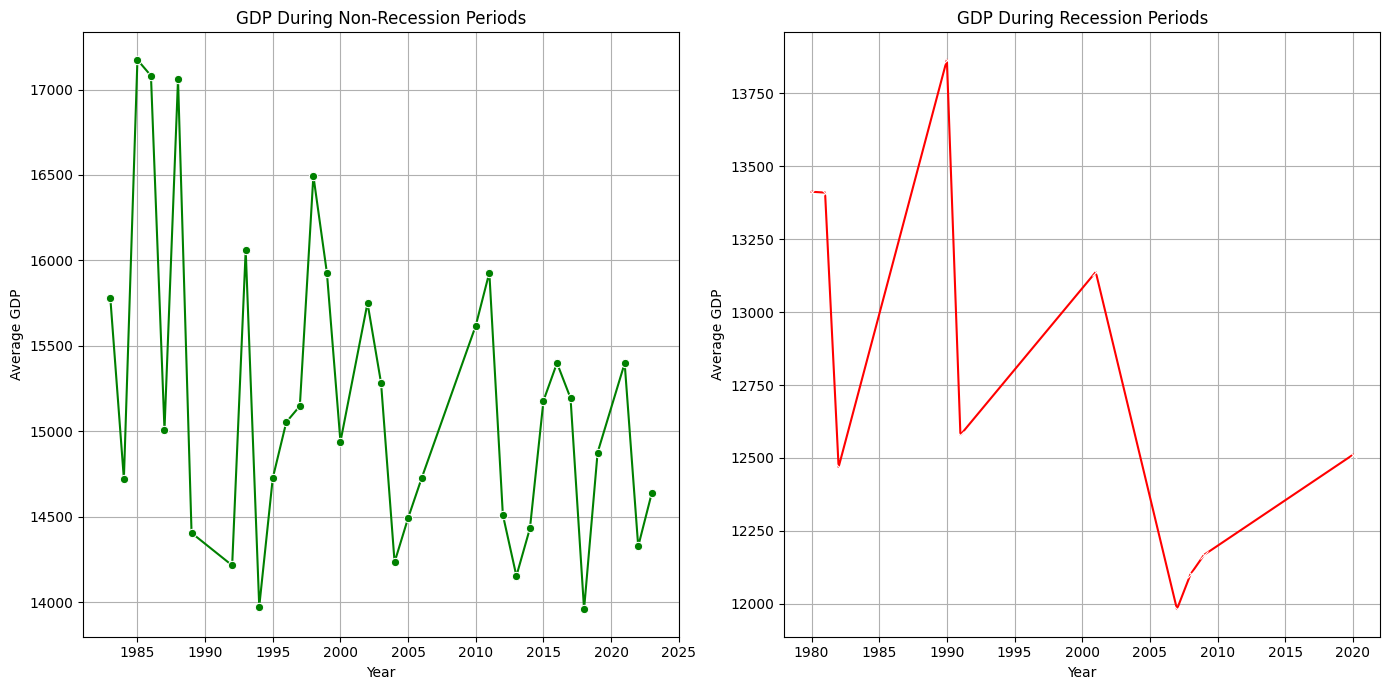

In [6]:
# Aggregate GDP by Year for both periods
gdp_yearly = df.groupby(['Year', 'Recession'])['GDP'].mean().reset_index()

plt.figure(figsize=(14, 7))

plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
sns.lineplot(data=gdp_yearly[gdp_yearly['Recession'] == 0], x='Year', y='GDP', marker='o', color='green')
plt.title('GDP During Non-Recession Periods')
plt.xlabel('Year')
plt.ylabel('Average GDP')
plt.grid(True)

plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
sns.lineplot(data=gdp_yearly[gdp_yearly['Recession'] == 1], x='Year', y='GDP', marker='x', color='red')
plt.title('GDP During Recession Periods')
plt.xlabel('Year')
plt.ylabel('Average GDP')
plt.grid(True)

plt.tight_layout()
plt.show()

```markdown
### TASK 1.5: Develop a Bubble plot for displaying the impact of seasonality on Automobile Sales. (1 point)
```

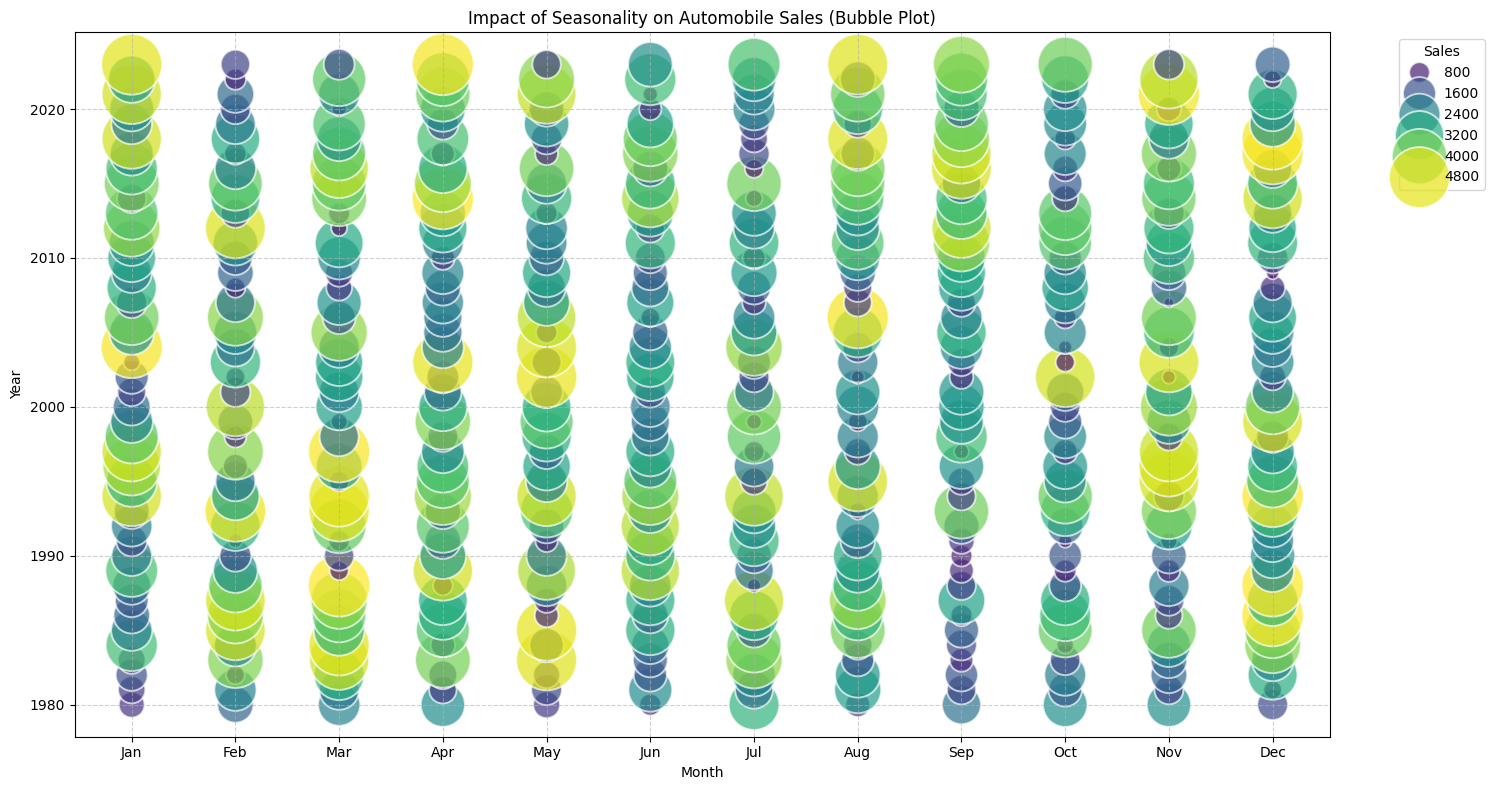

In [7]:
# Aggregate sales by Month and Year, with size reflecting total sales for that month
monthly_sales = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()

# For bubble plot, we need to map months to categories or use numerical values
# We'll use month as x, year as y, and sales as size

plt.figure(figsize=(15, 8))
sns.scatterplot(
    data=monthly_sales,
    x='Month',
    y='Year',
    size='Sales', # Size of bubbles based on sales
    hue='Sales', # Color based on sales
    sizes=(50, 2000), # Range of bubble sizes
    alpha=0.7,
    palette='viridis'
)

plt.title('Impact of Seasonality on Automobile Sales (Bubble Plot)')
plt.xlabel('Month')
plt.ylabel('Year')
plt.xticks(np.arange(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Sales', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

```markdown
### TASK 1.6: Use the functionality of Matplotlib to develop a scatter plot to identify the correlation between average vehicle price relate to the sales volume during recessions. (1 point)
```

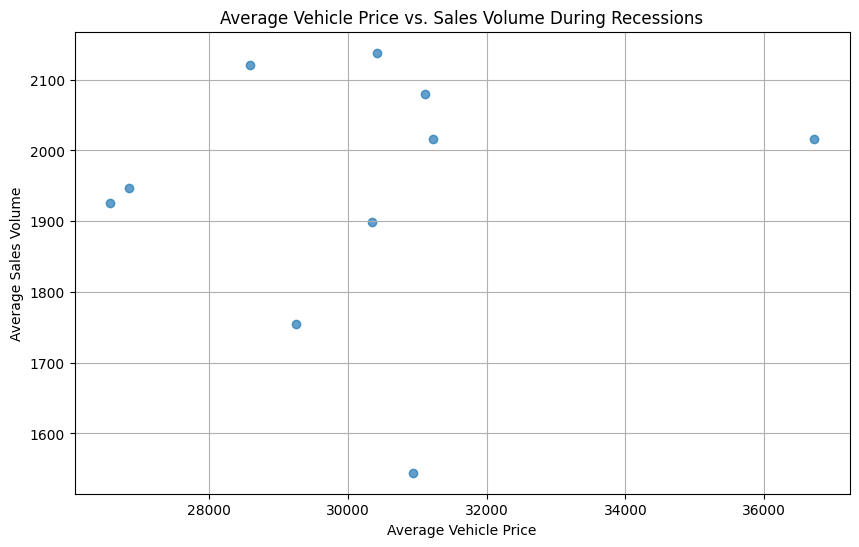

Correlation between Average Vehicle Price and Sales Volume during recessions: 0.08


In [8]:
# Filter for recession periods
df_recession = df[df['Recession'] == 1]

# Aggregate data for scatter plot (e.g., by year for overall trend)
recession_agg = df_recession.groupby('Year')[['Sales', 'Average_Vehicle_Price']].mean().reset_index()

plt.figure(figsize=(10, 6))
plt.scatter(x=recession_agg['Average_Vehicle_Price'], y=recession_agg['Sales'], alpha=0.7)
plt.title('Average Vehicle Price vs. Sales Volume During Recessions')
plt.xlabel('Average Vehicle Price')
plt.ylabel('Average Sales Volume')
plt.grid(True)
plt.show()

correlation = recession_agg['Average_Vehicle_Price'].corr(recession_agg['Sales'])
print(f"Correlation between Average Vehicle Price and Sales Volume during recessions: {correlation:.2f}")

```markdown
### TASK 1.7: Create a pie chart to display the portion of advertising expenditure of XYZAutomotives during recession and non-recession periods. (1 point)
```

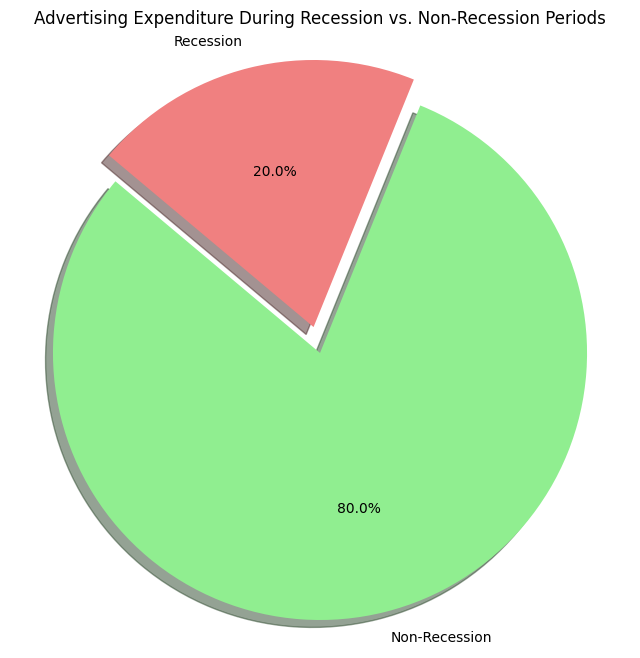

In [2]:
# Aggregate advertising expenditure by recession status
adv_exp_by_recession = df.groupby('Recession')['Advertising_Expenditure'].sum()

labels = ['Non-Recession', 'Recession']
sizes = adv_exp_by_recession.values
colors = ['lightgreen', 'lightcoral']
explode = (0.1, 0) # explode 1st slice (Recession)

plt.figure(figsize=(8, 8))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=140)
plt.title('Advertising Expenditure During Recession vs. Non-Recession Periods')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

```markdown
### TASK 1.8: Develop a pie chart to display the total Advertisement expenditure for each vehicle type during recession period. (1 point)
```

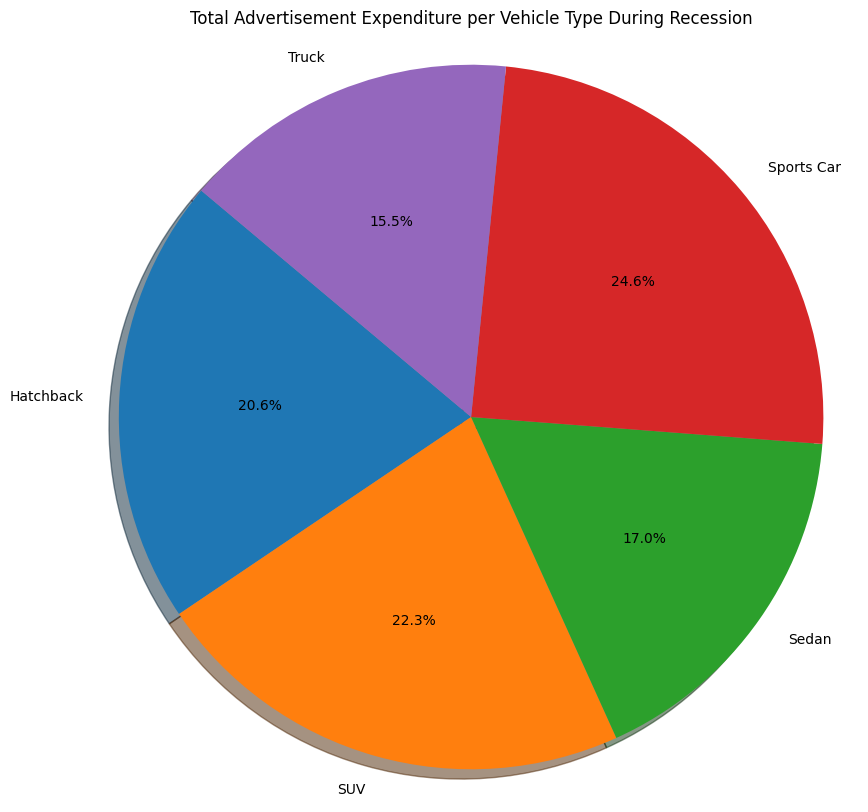

In [3]:
# Filter for recession periods and aggregate advertising expenditure by vehicle type
adv_exp_recession_by_type = df[df['Recession'] == 1].groupby('Vehicle_Type')['Advertising_Expenditure'].sum()

labels = adv_exp_recession_by_type.index
sizes = adv_exp_recession_by_type.values

plt.figure(figsize=(10, 10))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', shadow=True, startangle=140)
plt.title('Total Advertisement Expenditure per Vehicle Type During Recession')
plt.axis('equal')
plt.show()

```markdown
### TASK 1.9: Develop a line plot to analyse the effect of the unemployment rate on vehicle type and sales during the Recession Period. (1 point)
```

/tmp/ipykernel_2217/630212669.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Vehicle Type / Unemployment', loc='upper left')


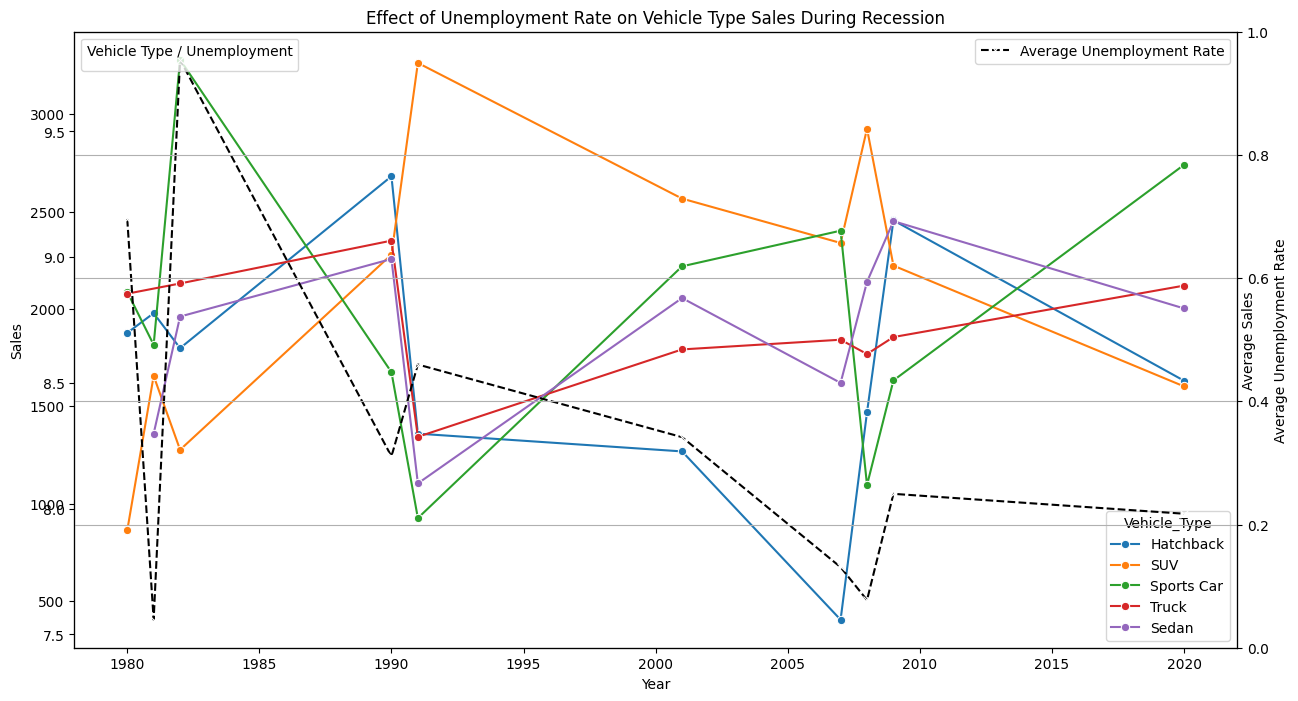

In [9]:
# Filter for recession periods
df_recession_unemp = df[df['Recession'] == 1]

# Aggregate sales and unemployment rate by Year and Vehicle_Type
recession_unemp_agg = df_recession_unemp.groupby(['Year', 'Vehicle_Type'])[['Sales', 'Unemployment_Rate']].mean().reset_index()

plt.figure(figsize=(15, 8))

sns.lineplot(data=recession_unemp_agg, x='Year', y='Sales', hue='Vehicle_Type', marker='o', palette='tab10', legend='full')
plt.twinx() # Create a twin Y-axis for unemployment rate
sns.lineplot(data=recession_unemp_agg.groupby('Year')['Unemployment_Rate'].mean().reset_index(), x='Year', y='Unemployment_Rate', color='black', linestyle='--', marker='x', label='Average Unemployment Rate')

plt.title('Effect of Unemployment Rate on Vehicle Type Sales During Recession')
plt.xlabel('Year')
plt.ylabel('Average Sales')
plt.twinx().set_ylabel('Average Unemployment Rate', color='black') # Label for the twin axis
plt.grid(True)
plt.legend(title='Vehicle Type / Unemployment', loc='upper left')
plt.show()

```markdown
## Part 2: Plotly and Dash Dashboard
```

```markdown
### TASK 2.1: Create a Dash application and give it a meaningful title. (2 points)
### TASK 2.2: Add drop-downs to your dashboard with appropriate titles and options. (1 point)
### TASK 2.3: Add a division for output display with appropriate 'id' and 'classname' property. (1 point)
### TASK 2.4: Creating Callbacks; Define the callback function to update the input container. (5 points)
### TASK 2.5: Create and display graphs for Recession Report Statistics. (3 points)
### TASK 2.6: Create and display graphs for Yearly Report Statistics. (2 points)

*(Note: To run a Dash app in Colab, you typically need to run it in a separate thread or use `jupyter_dash`. For simplicity and to demonstrate the code structure, I will provide the standard Dash app code. You would need to execute this in a `.py` file or adapt for `jupyter_dash` in a live Colab session.)*
```

In [10]:
# Sample data for Dash app (using the pre-generated df)

# Prepare data for Dash - aggregate as needed
year_options = [{'label': str(year), 'value': year} for year in df['Year'].unique()]
recession_options = [
    {'label': 'Non-Recession', 'value': 0},
    {'label': 'Recession', 'value': 1}
]

# Initialize the Dash app
app = dash.Dash(__name__)

# Define the app layout
app.layout = html.Div(
    children=[
        html.H1("Automobile Sales Dashboard", style={'textAlign': 'center', 'color': '#503D36', 'font-size': 24}),

        html.Div(
            [
                html.H2("Select Report Type:", style={'margin-right': '2em'}),
                dcc.Dropdown(
                    id='dropdown-report-type',
                    options=[
                        {'label': 'Recession Report', 'value': 'Recession Report'},
                        {'label': 'Yearly Report', 'value': 'Yearly Report'}
                    ],
                    value='Recession Report', # Default value
                    placeholder="Select a report type",
                    style={'width': '80%', 'padding': '3px', 'font-size': '20px', 'text-align-last': 'center'}
                ),
            ],
            style={'display': 'flex', 'margin-bottom': '20px'}
        ),

        html.Div(
            id='output-container-div',
            className='chart-grid', # Apply a class for potential styling
            children=[]
        )
    ]
)

# Define callback to update the output container based on report type selection
@app.callback(
    Output(component_id='output-container-div', component_property='children'),
    Input(component_id='dropdown-report-type', component_property='value')
)
def update_output_container(selected_report_type):
    if selected_report_type == 'Recession Report':
        # Recession Report Statistics (TASK 2.5)
        # Example: Sales vs. Unemployment Rate during recessions
        df_recession = df[df['Recession'] == 1].groupby(['Year'])[['Sales', 'Unemployment_Rate']].mean().reset_index()
        fig_sales_unemp = go.Figure()
        fig_sales_unemp.add_trace(go.Scatter(x=df_recession['Year'], y=df_recession['Sales'], mode='lines+markers', name='Avg Sales'))
        fig_sales_unemp.add_trace(go.Scatter(x=df_recession['Year'], y=df_recession['Unemployment_Rate'], mode='lines+markers', name='Avg Unemployment Rate', yaxis='y2'))
        fig_sales_unemp.update_layout(title='Recession: Sales vs. Unemployment Rate',
                                      xaxis_title='Year', yaxis_title='Sales',
                                      yaxis2=dict(title='Unemployment Rate', overlaying='y', side='right'))

        # Example: Advertising Expenditure by Vehicle Type during recession
        df_recession_adv = df[df['Recession'] == 1].groupby('Vehicle_Type')['Advertising_Expenditure'].sum().reset_index()
        fig_adv_pie = go.Figure(data=[go.Pie(labels=df_recession_adv['Vehicle_Type'], values=df_recession_adv['Advertising_Expenditure'], hole=.3)])
        fig_adv_pie.update_layout(title_text="Recession: Advertising Expenditure by Vehicle Type")

        return [
            html.Div(dcc.Graph(figure=fig_sales_unemp)),
            html.Div(dcc.Graph(figure=fig_adv_pie))
        ]

    elif selected_report_type == 'Yearly Report':
        # Yearly Report Statistics (TASK 2.6)
        # Example: Total Sales and Advertising Expenditure by Year
        df_yearly = df.groupby('Year')[['Sales', 'Advertising_Expenditure']].sum().reset_index()
        fig_yearly_sales_adv = make_subplots(specs=[[{"secondary_y": True}]])
        fig_yearly_sales_adv.add_trace(go.Scatter(x=df_yearly['Year'], y=df_yearly['Sales'], name='Total Sales'), secondary_y=False)
        fig_yearly_sales_adv.add_trace(go.Scatter(x=df_yearly['Year'], y=df_yearly['Advertising_Expenditure'], name='Total Advertising Expenditure'), secondary_y=True)
        fig_yearly_sales_adv.update_layout(title_text='Yearly: Total Sales vs. Advertising Expenditure')
        fig_yearly_sales_adv.update_xaxes(title_text='Year')
        fig_yearly_sales_adv.update_yaxes(title_text='Total Sales', secondary_y=False)
        fig_yearly_sales_adv.update_yaxes(title_text='Advertising Expenditure', secondary_y=True)

        # Example: Sales Distribution by Vehicle Type per Year (using a bar chart for an aggregated view)
        df_yearly_vehicle = df.groupby(['Year', 'Vehicle_Type'])['Sales'].sum().reset_index()
        fig_yearly_vehicle_sales = go.Figure()
        for v_type in df_yearly_vehicle['Vehicle_Type'].unique():
            df_subset = df_yearly_vehicle[df_yearly_vehicle['Vehicle_Type'] == v_type]
            fig_yearly_vehicle_sales.add_trace(go.Bar(x=df_subset['Year'], y=df_subset['Sales'], name=v_type))
        fig_yearly_vehicle_sales.update_layout(barmode='stack', title_text='Yearly: Sales Distribution by Vehicle Type')

        return [
            html.Div(dcc.Graph(figure=fig_yearly_sales_adv)),
            html.Div(dcc.Graph(figure=fig_yearly_vehicle_sales))
        ]

    return html.Div([]) # Return empty div if no report type is selected or an error occurs


if __name__ == '__main__':
    # To run this Dash app in a Colab environment, you would typically use `jupyter_dash`
    # or run it as a standalone Python script and access it via port forwarding.
    # For demonstration, we'll just show the app structure.
    print("Dash application code generated. To run, save this code to a .py file and execute it, or use jupyter_dash in a notebook environment.")
    # app.run_server(debug=True, mode='inline') # This would work with jupyter_dash in Colab
    # For a simple local run:
    # app.run_server(debug=True)

Dash application code generated. To run, save this code to a .py file and execute it, or use jupyter_dash in a notebook environment.
